<a href="https://colab.research.google.com/github/LamponeHub/System-Analysis/blob/main/%D0%98%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D1%81%D0%BA%D0%B8%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_%D0%92%D0%B0%D1%80%D0%B3%D0%B0%D0%BD%D0%BE%D0%B2%D0%B0_%D0%9F_%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ошибка: Файл 'wine_reviews.csv' не найден. Пожалуйста, загрузите его через панель файлов или используйте files.upload().


Saving wine_reviews.csv to wine_reviews.csv
1. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ

Размер данных: 20000 строк, 10 столбцов

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      20000 non-null  object 
 1   description  20000 non-null  object 
 2   designation  13999 non-null  object 
 3   points       20000 non-null  int64  
 4   price        18198 non-null  float64
 5   province     20000 non-null  object 
 6   region_1     16543 non-null  object 
 7   region_2     8058 non-null   object 
 8   variety      20000 non-null  object 
 9   winery       20000 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.5+ MB
None

Первые 5 строк:
  country                                        description designation  \
0      US  With a delicate, silky mouthfeel and bright ac...         NaN   
1   Ita

/tmp/ipykernel_5464/1068766716.py:249: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_rating.values, y=top_countries_rating.index, ax=axes[0, 0], palette='viridis')


Дополнительные графики сохранены в файл 'wine_additional_plots.png'

ИТОГОВЫЕ ВЫВОДЫ

1. ОБЩИЕ ХАРАКТЕРИСТИКИ:
   - Всего записей: 18881
   - Уникальных стран: 38
   - Уникальных сортов: 420
   - Уникальных виноделен: 7454

2. ЦЕНОВАЯ СТАТИСТИКА:
   - Средняя цена: $32.49
   - Медианная цена: $24.00
   - Максимальная цена: $2300.00
   - Минимальная цена: $5.00

3. РЕЙТИНГИ:
   - Средний рейтинг: 87.90
   - Медианный рейтинг: 88.00
   - Максимальный рейтинг: 100
   - Минимальный рейтинг: 80

4. КОРРЕЛЯЦИЯ:
   - Корреляция между ценой и рейтингом: 0.397
   - Умеренная связь

5. ЛИДЕРЫ:
   - Страна с самым дорогим вином: France
   - Самый популярный сорт: Pinot Noir
   - Лучшая провинция по рейтингу: Martinborough Terrace
   - Винодельня с наивысшим средним рейтингом: Sloan

6. РАСПРЕДЕЛЕНИЕ ПО ТИПАМ ВИН:
wine_color
Red      7812
Other    6456
White    4156
Rosé      457
Name: count, dtype: int64


Анализ завершен! Все графики сохранены.


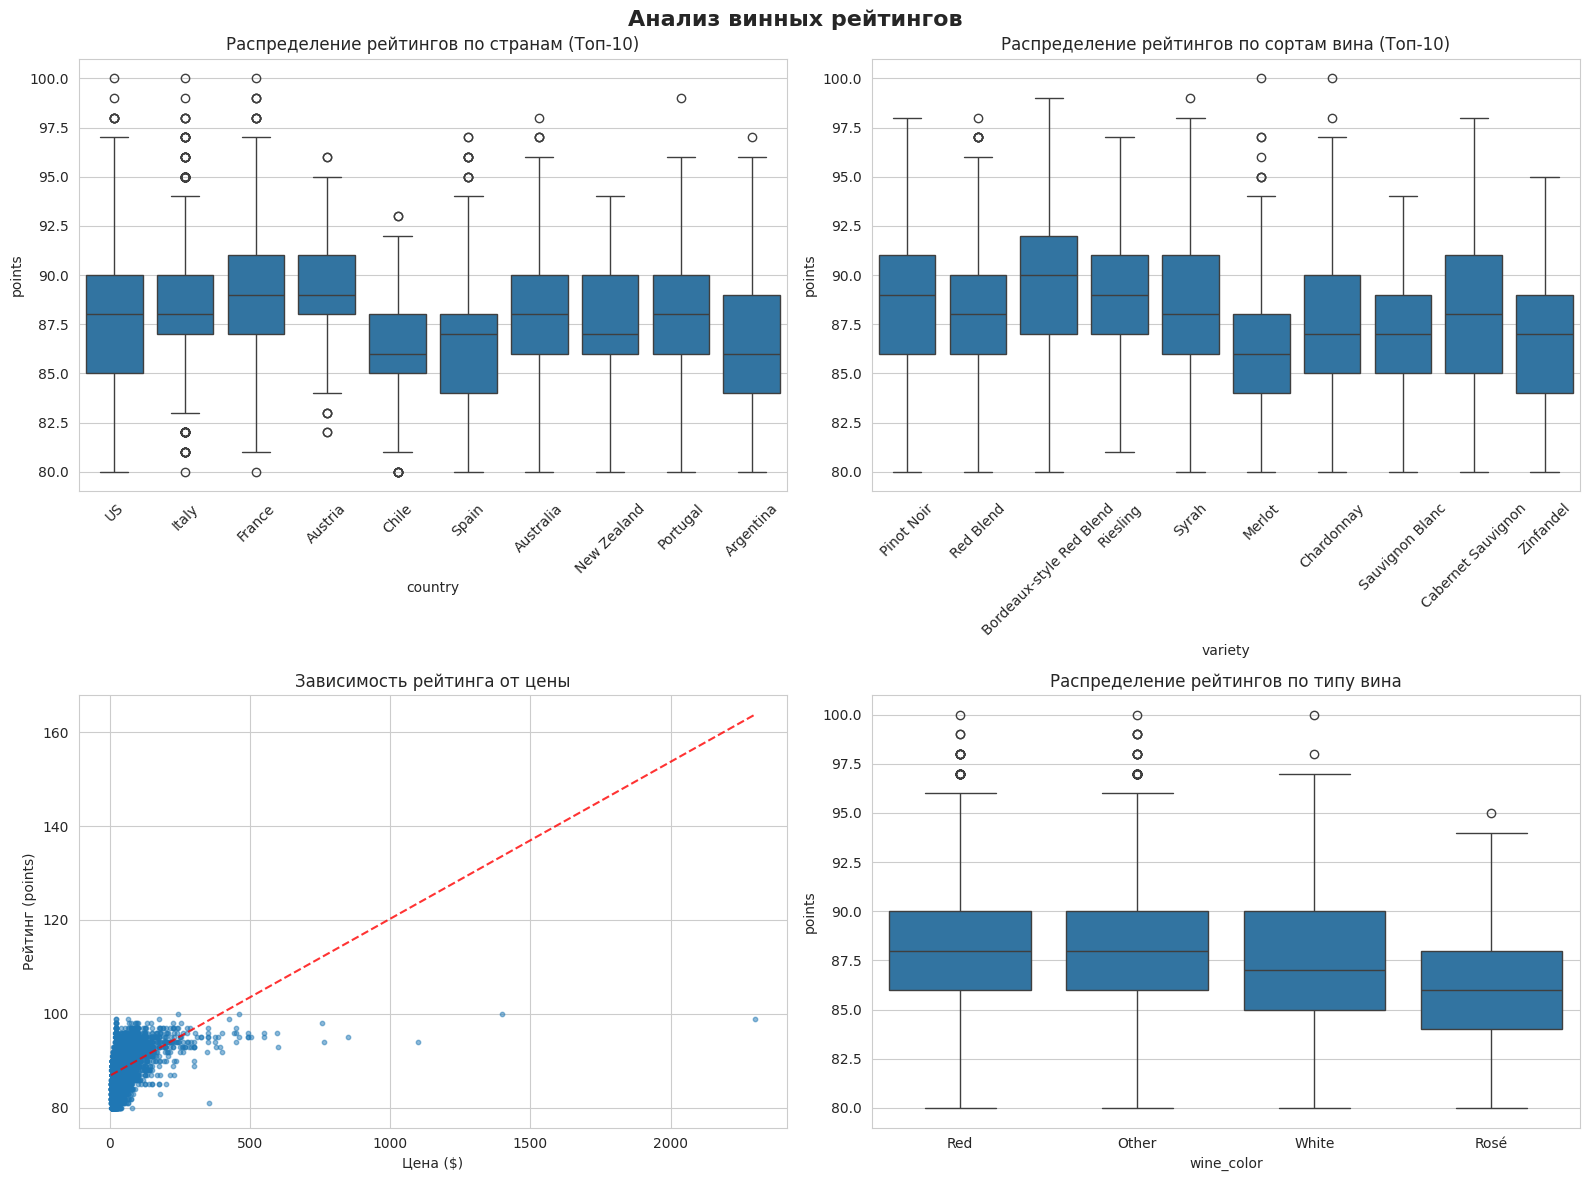

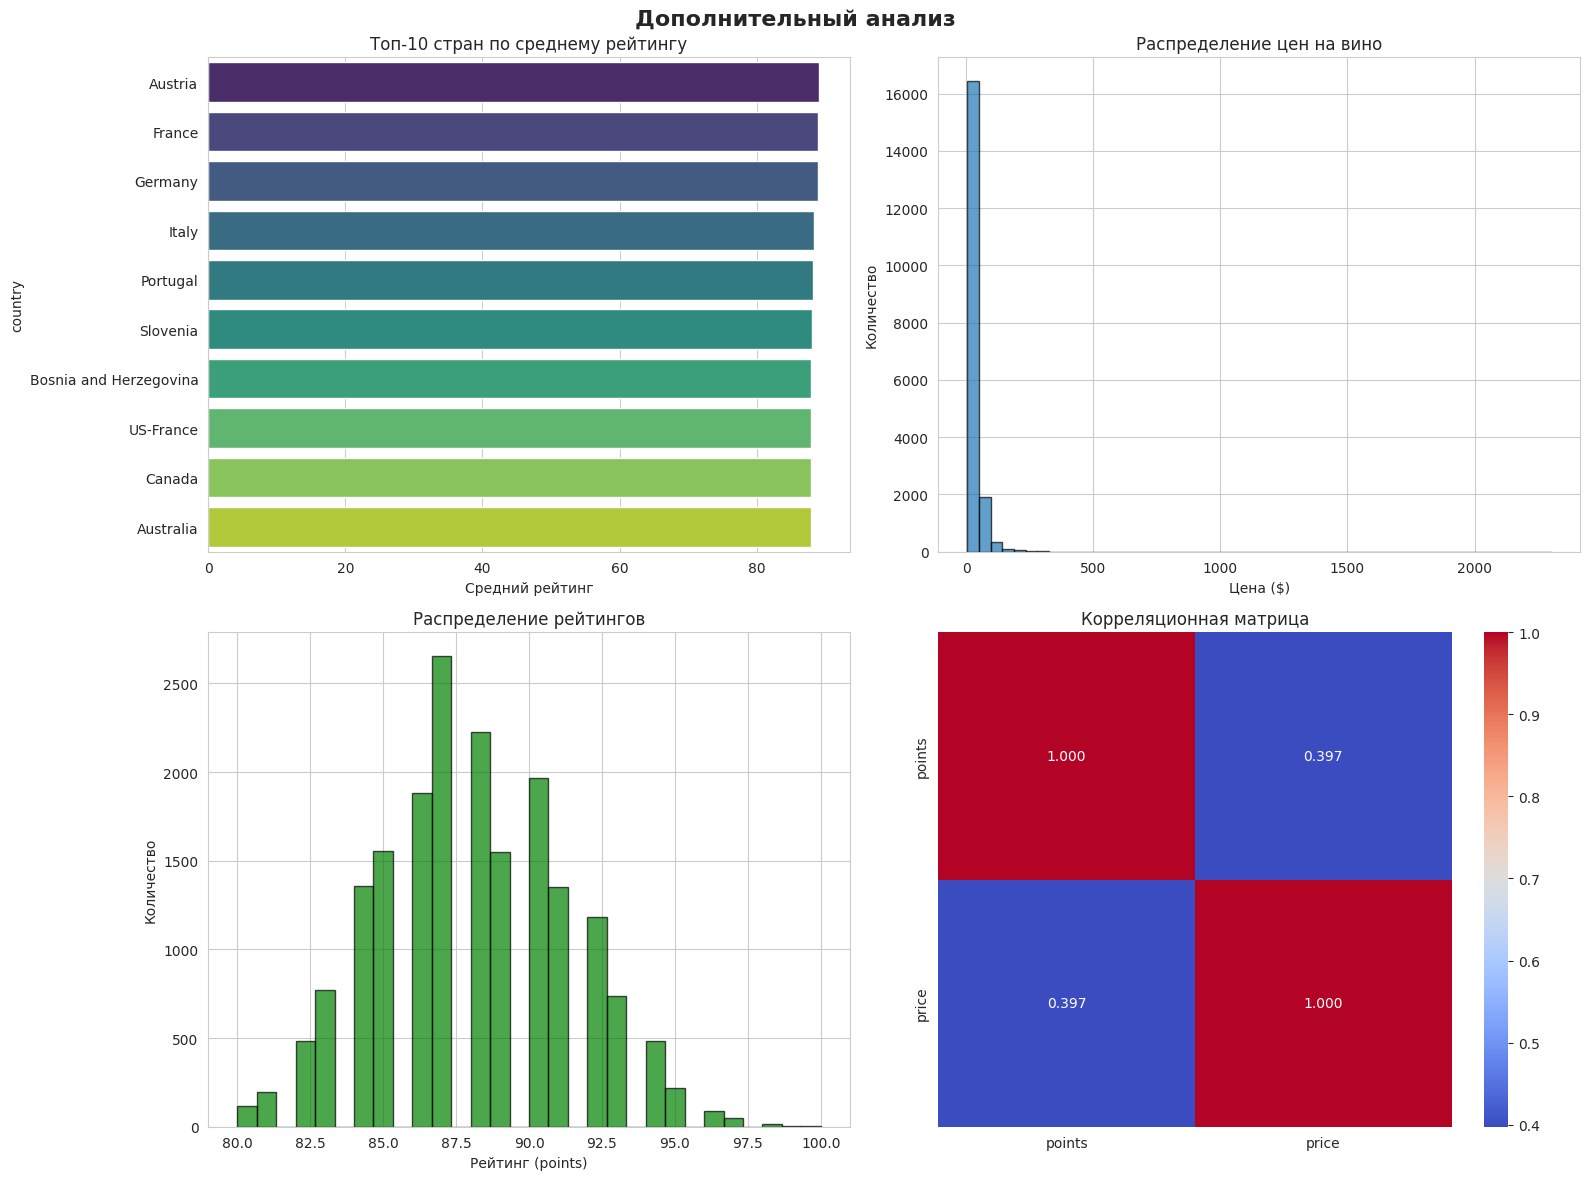

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

# --- ЗАГРУЗКА ФАЙЛА ---
# Если файла еще нет в системе, раскомментируйте следующие две строки:
# uploaded = files.upload()
# -----------------------

# Загрузка данных
try:
    df = pd.read_csv('wine_reviews.csv')
except FileNotFoundError:
    print("Ошибка: Файл 'wine_reviews.csv' не найден. Пожалуйста, загрузите его через панель файлов или используйте files.upload().")
    # Принудительный вызов диалога загрузки, если файл не найден
    uploaded = files.upload()
    df = pd.read_csv('wine_reviews.csv')

# 1. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ
print("=" * 60)
print("1. ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ")
print("=" * 60)
print(f"\nРазмер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nИнформация о датасете:")
print(df.info())
print("\nПервые 5 строк:")
print(df.head())
print("\nСтатистика по числовым признакам:")
print(df.describe())

# 2. ОБРАБОТКА ПУСТЫХ ЗНАЧЕНИЙ
print("\n" + "=" * 60)
print("2. ОБРАБОТКА ПУСТЫХ ЗНАЧЕНИЙ")
print("=" * 60)
print("\nКоличество пропусков до обработки:")
print(df.isnull().sum())
print(f"\nПроцент пропусков по столбцам:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Создаем копию для обработки
df_clean = df.copy()

# Заполним пропуски в price медианой
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())

# Заполним пропуски в категориальных признаках значением 'Unknown'
categorical_cols = ['country', 'region_1', 'region_2', 'variety', 'winery', 'designation']
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

print(f"\nКоличество пропусков после обработки:")
print(df_clean.isnull().sum())

# 3. УДАЛЕНИЕ ДУБЛИКАТОВ
print("\n" + "=" * 60)
print("3. УДАЛЕНИЕ ДУБЛИКАТОВ")
print("=" * 60)
print(f"Количество дубликатов: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print(f"Размер данных после удаления дубликатов: {df_clean.shape}")

# 4. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
print("\n" + "=" * 60)
print("4. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("=" * 60)
print("\nОбщая статистика:")
print(df_clean.describe())

print("\n--- Анализ по признакам ---")
print(f"\nСтраны: {df_clean['country'].nunique()} уникальных")
print(f"Регионы (province): {df_clean['province'].nunique()} уникальных")
print(f"Сорта вина (variety): {df_clean['variety'].nunique()} уникальных")
print(f"Винодельни (winery): {df_clean['winery'].nunique()} уникальных")

# 5. АНАЛИЗ ЗАВИСИМОСТЕЙ
print("\n" + "=" * 60)
print("5. АНАЛИЗ ЗАВИСИМОСТЕЙ")
print("=" * 60)

# Добавим колонку с континентами
country_to_continent = {
    'Italy':'Europe', 'Portugal':'Europe', 'US':'North America',
    'Spain':'Europe', 'France':'Europe', 'Germany':'Europe',
    'Argentina':'Latin America', 'Chile':'Latin America',
    'Australia': 'Oceania', 'Austria': 'Europe',
    'South Africa': 'Africa', 'New Zealand': 'Oceania',
    'Israel': 'Asia', 'Hungary':'Europe', 'Greece':'Europe',
    'Romania':'Europe', 'Mexico':'Latin America', 'Canada':'North America',
    'Turkey': 'Asia', 'Czech Republic': 'Europe', 'Slovenia': 'Europe',
    'Luxembourg': 'Europe', 'Croatia': 'Europe', 'Georgia':'Europe',
    'Uruguay': 'Latin America', 'England': 'Europe', 'Lebanon': 'Asia',
    'Serbia': 'Europe', 'Brazil': 'Latin America', 'Moldova': 'Europe',
    'Morocco':'Africa', 'Peru':'Latin America', 'India':'Asia',
    'Bulgaria':'Europe', 'Cyprus': 'Europe', 'Armenia':'Asia',
    'Switzerland':'Europe', 'Bosnia and Herzegovina':'Europe',
    'Ukraine':'Europe', 'Slovakia':'Europe', 'Macedonia':'Europe',
    'China':'Asia', 'Egypt':'Africa'
}

df_clean['continent'] = df_clean['country'].map(country_to_continent).fillna('Other')

# Определим цвет вина по сорту
red_varieties = ['Cabernet Sauvignon', 'Merlot', 'Pinot Noir', 'Syrah', 'Malbec',
                 'Tempranillo', 'Sangiovese', 'Zinfandel', 'Nebbiolo', 'Shiraz',
                 'Cabernet Franc', 'Grenache', 'Barbera', 'Nero dAvola']
white_varieties = ['Chardonnay', 'Sauvignon Blanc', 'Riesling', 'Pinot Grigio',
                   'Chenin Blanc', 'Gewürztraminer', 'Viognier', 'Muscadet',
                   'Albariño', 'Grüner Veltliner', 'Verdejo']
rose_varieties = ['Rosé', 'Pinot Noir Rosé']

def get_wine_color(variety):
    variety_str = str(variety).lower()
    if any(v.lower() in variety_str for v in rose_varieties) or 'rosé' in variety_str or 'rose' in variety_str:
        return 'Rosé'
    elif any(v.lower() in variety_str for v in white_varieties):
        return 'White'
    elif any(v.lower() in variety_str for v in red_varieties):
        return 'Red'
    else:
        return 'Other'

df_clean['wine_color'] = df_clean['variety'].apply(get_wine_color)

# 6. ОТВЕТЫ НА ВОПРОСЫ
print("\n" + "=" * 60)
print("6. ОТВЕТЫ НА ВОПРОСЫ")
print("=" * 60)

# Вопрос 1: Самое дорогое и самое дешевое вино
print("\n--- Вопрос 1: Самое дорогое и самое дешевое вино ---")
most_expensive = df_clean.loc[df_clean['price'].idxmax()]
cheapest = df_clean.loc[df_clean['price'].idxmin()]

print(f"\nСАМОЕ ДОРОГОЕ ВИНО:")
print(f"Страна: {most_expensive['country']}")
print(f"Винодельня: {most_expensive['winery']}")
print(f"Название: {most_expensive['designation']}")
print(f"Сорт: {most_expensive['variety']}")
print(f"Цена: ${most_expensive['price']}")
print(f"Рейтинг: {most_expensive['points']}")

print(f"\nСАМОЕ ДЕШЕВОЕ ВИНО:")
print(f"Страна: {cheapest['country']}")
print(f"Винодельня: {cheapest['winery']}")
print(f"Название: {cheapest['designation']}")
print(f"Сорт: {cheapest['variety']}")
print(f"Цена: ${cheapest['price']}")
print(f"Рейтинг: {cheapest['points']}")

# Вопрос 2: Самый популярный сорт вина по странам
print("\n--- Вопрос 2: Самый популярный сорт вина по странам ---")
top_varieties_by_country = df_clean.groupby(['country', 'variety']).size().reset_index(name='count')
top_varieties_by_country = top_varieties_by_country.sort_values(['country', 'count'], ascending=[True, False])
top_varieties_by_country = top_varieties_by_country.groupby('country').first().reset_index()
print(top_varieties_by_country.head(10))

# Вопрос 3: Лучшие провинции по рейтингу
print("\n--- Вопрос 3: Лучшие провинции по рейтингу ---")
province_rating = df_clean.groupby('province')['points'].mean().sort_values(ascending=False)
print("\nТоп-10 провинций по среднему рейтингу:")
print(province_rating.head(10))

# Корреляция цены и рейтинга
print("\n--- Корреляция цены и рейтинга ---")
correlation = df_clean['price'].corr(df_clean['points'])
print(f"Коэффициент корреляции Пирсона: {correlation:.3f}")
print(f"Корреляция Спирмена: {df_clean['price'].corr(df_clean['points'], method='spearman'):.3f}")

# Вопрос 4: Вина с наилучшим рейтингом
print("\n--- Вопрос 4: Вина с наилучшим рейтингом ---")
top_rated_wines = df_clean.nlargest(10, 'points')[['winery', 'designation', 'variety', 'country', 'points', 'price']]
print(top_rated_wines)

# Вопрос 5: Винодельни с самыми дорогими и высоко оцененными винами
print("\n--- Вопрос 5: Винодельни с самыми дорогими винами ---")
top_expensive_wineries = df_clean.groupby('winery')['price'].mean().sort_values(ascending=False).head(10)
print(top_expensive_wineries)

print("\n--- Винодельни с наивысшими рейтингами ---")
top_rated_wineries = df_clean.groupby('winery')['points'].mean().sort_values(ascending=False).head(10)
print(top_rated_wineries)

# Вопрос 6: Вина с наименьшим рейтингом
print("\n--- Вопрос 6: Вина с наименьшим рейтингом ---")
lowest_rated = df_clean.nsmallest(10, 'points')[['winery', 'designation', 'variety', 'country', 'province', 'points', 'price']]
print(lowest_rated)

print("\n--- Страны с наименьшим средним рейтингом ---")
lowest_rated_countries = df_clean.groupby('country')['points'].mean().sort_values().head(10)
print(lowest_rated_countries)

# ВИЗУАЛИЗАЦИЯ
print("\n" + "=" * 60)
print("ВИЗУАЛИЗАЦИЯ ДАННЫХ")
print("=" * 60)

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. Box plot рейтингов по странам
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ винных рейтингов', fontsize=16, fontweight='bold')

# Top countries by count
top_countries = df_clean['country'].value_counts().head(10).index
df_top_countries = df_clean[df_clean['country'].isin(top_countries)]

sns.boxplot(data=df_top_countries, x='country', y='points', ax=axes[0, 0])
axes[0, 0].set_title('Распределение рейтингов по странам (Топ-10)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Box plot рейтингов по сортам вина
top_varieties = df_clean['variety'].value_counts().head(10).index
df_top_varieties = df_clean[df_clean['variety'].isin(top_varieties)]

sns.boxplot(data=df_top_varieties, x='variety', y='points', ax=axes[0, 1])
axes[0, 1].set_title('Распределение рейтингов по сортам вина (Топ-10)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Scatter plot: цена vs рейтинг
axes[1, 0].scatter(df_clean['price'], df_clean['points'], alpha=0.5, s=10)
axes[1, 0].set_xlabel('Цена ($)')
axes[1, 0].set_ylabel('Рейтинг (points)')
axes[1, 0].set_title('Зависимость рейтинга от цены')

# Добавим линию тренда
z = np.polyfit(df_clean['price'].dropna(), df_clean['points'].dropna(), 1)
p = np.poly1d(z)
axes[1, 0].plot(df_clean['price'].sort_values(), p(df_clean['price'].sort_values()), "r--", alpha=0.8)

# 4. Распределение рейтингов по цветам вина
sns.boxplot(data=df_clean, x='wine_color', y='points', ax=axes[1, 1])
axes[1, 1].set_title('Распределение рейтингов по типу вина')

plt.tight_layout()
plt.savefig('wine_analysis_plots.png', dpi=300, bbox_inches='tight')
print("\nГрафики сохранены в файл 'wine_analysis_plots.png'")

# Дополнительные графики
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Дополнительный анализ', fontsize=16, fontweight='bold')

# 5. Топ-10 стран по среднему рейтингу
top_countries_rating = df_clean.groupby('country')['points'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_rating.values, y=top_countries_rating.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Топ-10 стран по среднему рейтингу')
axes[0, 0].set_xlabel('Средний рейтинг')

# 6. Распределение цен
axes[0, 1].hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Распределение цен на вино')
axes[0, 1].set_xlabel('Цена ($)')
axes[0, 1].set_ylabel('Количество')

# 7. Распределение рейтингов
axes[1, 0].hist(df_clean['points'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Распределение рейтингов')
axes[1, 0].set_xlabel('Рейтинг (points)')
axes[1, 0].set_ylabel('Количество')

# 8. Корреляционная матрица
numeric_df = df_clean[['points', 'price']].dropna()
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=axes[1, 1], fmt='.3f')
axes[1, 1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.savefig('wine_additional_plots.png', dpi=300, bbox_inches='tight')
print("Дополнительные графики сохранены в файл 'wine_additional_plots.png'")

# ФИНАЛЬНЫЙ ОТЧЕТ
print("\n" + "=" * 60)
print("ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 60)

print(f"""
1. ОБЩИЕ ХАРАКТЕРИСТИКИ:
   - Всего записей: {len(df_clean)}
   - Уникальных стран: {df_clean['country'].nunique()}
   - Уникальных сортов: {df_clean['variety'].nunique()}
   - Уникальных виноделен: {df_clean['winery'].nunique()}

2. ЦЕНОВАЯ СТАТИСТИКА:
   - Средняя цена: ${df_clean['price'].mean():.2f}
   - Медианная цена: ${df_clean['price'].median():.2f}
   - Максимальная цена: ${df_clean['price'].max():.2f}
   - Минимальная цена: ${df_clean['price'].min():.2f}

3. РЕЙТИНГИ:
   - Средний рейтинг: {df_clean['points'].mean():.2f}
   - Медианный рейтинг: {df_clean['points'].median():.2f}
   - Максимальный рейтинг: {df_clean['points'].max()}
   - Минимальный рейтинг: {df_clean['points'].min()}

4. КОРРЕЛЯЦИЯ:
   - Корреляция между ценой и рейтингом: {correlation:.3f}
   {'- Слабая положительная связь' if 0 < correlation < 0.3 else '- Умеренная связь' if 0.3 <= correlation < 0.7 else '- Сильная связь'}

5. ЛИДЕРЫ:
   - Страна с самым дорогим вином: {most_expensive['country']}
   - Самый популярный сорт: {df_clean['variety'].mode()[0]}
   - Лучшая провинция по рейтингу: {province_rating.index[0]}
   - Винодельня с наивысшим средним рейтингом: {top_rated_wineries.index[0]}

6. РАСПРЕДЕЛЕНИЕ ПО ТИПАМ ВИН:
{df_clean['wine_color'].value_counts()}
""")

print("\nАнализ завершен! Все графики сохранены.")